This is in separate notebook because open3d lib didn't want to work with other libraries

In [1]:
import open3d as o3d
import numpy as np
from pathlib import Path
from pyntcloud import PyntCloud
import point_cloud_utils as pcu
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
model_path = r"C:\Users\julia\PycharmProjects\urb3drecon\data\truck\model.ply"

In [3]:
model_pc = PyntCloud.from_file(model_path)

In [75]:
# sensor_dirs are stored in the normal channel and are encoded as unit
# vectors pointing from the point to the scanner
pts, sensor_dirs = pcu.load_mesh_vf(model_path)

# Optionally delete point whose normal is at an oblique (greather than 85 degree) angle with the sensor direction
drop_angle = np.deg2rad(85.0)

# Size of the neighborhood used for each point
num_nbrs = 32

# n are the fitted normals
# n_idx are used to delete points which were filterd (ignore this if you don't pass in drop_angle)
_, n = pcu.estimate_point_cloud_normals_knn(pts, num_nbrs, view_directions=sensor_dirs)

In [76]:
n

array([[ 0.9097925 , -0.31053746,  0.2753982 ],
       [ 0.8191558 ,  0.21692392, -0.53096867],
       [-0.03885777,  0.14522205,  0.9886357 ],
       ...,
       [ 0.11209024,  0.63480777,  0.7644965 ],
       [-0.2001349 ,  0.60180855,  0.7731575 ],
       [-0.31854475,  0.6074942 ,  0.7276538 ]], dtype=float32)

In [4]:
model_pc.points

,x,y,z,a,q0,q1,q2,q3,s0,s1,...,sh13_z,sh14_x,sh14_y,sh14_z,sh15_x,sh15_y,sh15_z,red,green,blue
0,-0.064733,0.119897,0.023411,-4.911214,0.870997,0.929403,0.413836,0.935158,-6.445889,-6.499992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.011220,0.093267
1,0.111417,-0.945760,-0.140943,-2.915669,0.370942,0.623973,0.272116,0.770452,-4.154178,-4.162440,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.175078,0.239356,0.360057
2,-0.267213,0.143360,-0.258143,-3.552155,0.933949,0.130693,0.943258,0.587451,-5.567338,-5.635808,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.033307
3,-0.023564,0.239410,0.030673,-3.145328,0.866848,0.563657,0.769636,0.405542,-5.926701,-6.015903,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.239073,0.347609
4,-0.098971,0.278061,0.127272,-3.074549,0.916686,0.587869,0.253023,0.591227,-5.185241,-5.210234,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454236,0.522849,0.521839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136024,0.415271,0.661189,-0.252745,-2.891380,0.448282,0.446808,0.457195,0.184643,-3.899276,-3.861751,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.161294,0.236551,0.389560
136025,0.368790,0.341244,-0.118044,-3.966955,0.556655,0.440790,0.204672,0.979341,-4.772062,-4.747161,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
136026,0.270599,0.132579,0.178239,-3.637907,0.729817,0.718795,0.380449,0.860253,-5.546193,-5.622743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.182841,0.327979
136027,0.471661,-0.442204,-0.158911,-4.169721,0.025241,0.312886,0.461717,0.661480,-5.811446,-5.693813,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.046816,0.120505,0.205079


In [78]:
model_pc.points[['x', 'y', 'z']] - n 

,x,y,z
0,-1.644386,0.169950,-0.260303
1,-0.807573,-0.059289,0.682560
2,0.159230,0.006082,-1.280900
3,-0.631981,0.241342,0.057414
4,-0.358695,0.191388,-1.121245
...,...,...,...
2706350,-2.392651,1.231128,-1.289773
2706351,-9.448706,5.730904,-0.139971
2706352,-2.229798,1.878284,-0.977074
2706353,-1.083359,-0.867689,-1.036391


In [79]:
np.array([1, 2, 3]) * np.array([3, 3, 3])

array([3, 6, 9])

In [80]:
np.min(n, axis=0), np.max(n, axis=0)

(array([-0.7949035 , -0.7979608 , -0.79252726], dtype=float32),
 array([0.99999994, 0.99999964, 0.9999999 ], dtype=float32))

In [82]:
def compute_colors_from_harmonics(points, normals):
    SH_C0 = 0.28209479177387814
    SH_C1 = 0.4886025119029199
    SH_C2 = [1.0925484305920792,
            -1.0925484305920792,
            0.31539156525252005,
            -1.0925484305920792,
            0.5462742152960396
    ]
    SH_C3 = [
        -0.5900435899266435,
        2.890611442640554,
        -0.4570457994644658,
        0.3731763325901154,
        -0.4570457994644658,
        1.445305721320277,
        -0.5900435899266435
    ]
    # p = (points[['x', 'y', 'z']].values - normals).reshape(-1, 3)
    p = normals
    x = p[:, [0]]
    y = p[:, [1]]
    z = p[:, [2]]
    
    sh0s = SH_C0 * points[['sh0_x', 'sh0_y', 'sh0_z']].values
    
    sh1s =  SH_C1 * (-y * points[['sh1_x', 'sh1_y', 'sh1_z']].values + z * points[['sh2_x', 'sh2_y', 'sh2_z']].values - x * points[['sh3_x', 'sh3_y', 'sh3_z']].values)
    

    xx = p[:, [0]] ** 2 
    yy = p[:, [1]] ** 2
    zz = p[:, [2]] ** 2
    xy = x * y
    xz = x * z
    yz = y * z
    sh2s = SH_C2[0] * xy * points[['sh4_x', 'sh4_y', 'sh4_z']].values + SH_C2[1] * yz * points[['sh5_x', 'sh5_y', 'sh5_z']].values + SH_C2[2] * (2 * zz - xx - yy) * points[['sh6_x', 'sh6_y', 'sh6_z']].values + SH_C2[3] * xz * points[['sh7_x', 'sh7_y', 'sh7_z']].values + SH_C2[4] * (xx - yy) * points[['sh8_x', 'sh8_y', 'sh8_z']].values
    
    sh3s = SH_C3[0] * y * (3. * xx - yy) * points[['sh9_x', 'sh9_y', 'sh9_z']].values + SH_C3[1] * xy * z * points[['sh10_x', 'sh10_y', 'sh10_z']].values + SH_C3[2] * y * (4. * zz - xx - yy) * points[['sh11_x', 'sh11_y', 'sh11_z']].values + SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * points[['sh12_x', 'sh12_y', 'sh12_z']].values + SH_C3[4] * x * (4.0 * zz - xx - yy) * points[['sh13_x', 'sh13_y', 'sh13_z']].values + SH_C3[5] * z * (xx - yy) * points[['sh14_x', 'sh14_y', 'sh14_z']].values + SH_C3[6] * x * (xx - 3.0 * yy) * points[['sh15_x', 'sh15_y', 'sh15_z']].values
    
    res = sh0s + sh1s + sh2s + sh3s
    
    return np.where(res > 0, res, 0)

In [83]:
colors = compute_colors_from_harmonics(model_pc.points, n)

In [84]:
np.sum(colors[:, 0] > 1.0)

34911

(array([1.810821e+06, 7.788980e+05, 1.090430e+05, 6.784000e+03,
        6.690000e+02, 9.600000e+01, 2.600000e+01, 1.300000e+01,
        4.000000e+00, 1.000000e+00]),
 array([0.        , 0.3962585 , 0.79251701, 1.18877554, 1.58503401,
        1.98129249, 2.37755108, 2.77380943, 3.17006803, 3.56632638,
        3.96258497]),
 <BarContainer object of 10 artists>)

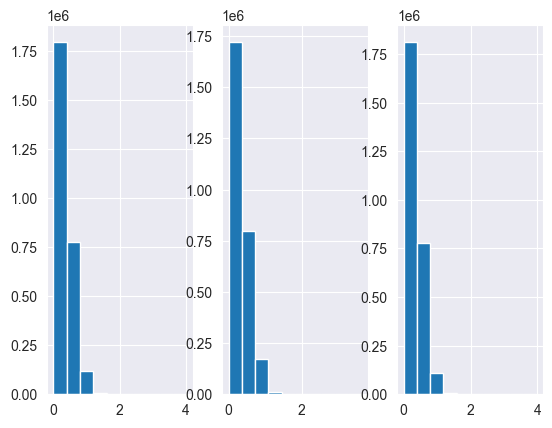

In [85]:
plt.subplot(1, 3, 1)
plt.hist(colors[:, 0])
plt.subplot(1, 3, 2)
plt.hist(colors[:, 1])
plt.subplot(1, 3, 3)
plt.hist(colors[:, 2])

In [86]:
model_pc.points.loc[:, 'red'] = colors[:, 0]
model_pc.points.loc[:, 'green'] = colors[:, 1]
model_pc.points.loc[:, 'blue'] = colors[:, 2]

In [88]:
model_pc.to_file("../results/c7/whale/colors_model.ply")

In [28]:
r_1

array([[-5.96467406e-03, -5.29630575e-03, -7.46935513e-03],
       [ 1.86993129e-04,  2.22313858e-04,  2.53133569e-03],
       [-1.02910176e-02, -1.20486952e-02, -1.06166005e-02],
       [-2.03548581e-03, -2.35354085e-03, -2.48595676e-03],
       [-2.82961316e-02, -2.32792217e-02, -2.08549406e-02],
       [ 5.76229068e-04,  7.71325780e-04, -1.41117898e-05],
       [ 8.88771098e-03, -1.70557965e-02, -9.00180452e-03],
       [-8.34993366e-03, -8.65427218e-03, -9.46132839e-03],
       [-8.66267597e-04, -1.42622693e-03, -1.93585723e-03],
       [ 8.87208269e-04, -5.42046176e-03, -6.59316825e-03],
       [-8.48000986e-04,  5.31585421e-03,  5.80310216e-03],
       [-6.48344774e-03, -1.49387158e-02, -3.05383820e-02],
       [-2.01966046e-04, -1.37198585e-04, -3.23062588e-04],
       [ 4.49591596e-03,  5.13772946e-03,  5.11580426e-03],
       [ 1.59075707e-02,  8.79015960e-03,  7.14447815e-03],
       [ 2.97417734e-02,  2.44924277e-02,  9.16816667e-03],
       [-1.82482094e-04,  4.28391068e-05

In [18]:
r_1

array([[ 0.00286266, -0.01719058, -0.02098264, ...,  0.02597624,
         0.03359259,  0.01350135],
       [-0.01783724,  0.01417158,  0.01664465, ..., -0.01463804,
        -0.06240278, -0.10009476],
       [-0.00037298,  0.00231852, -0.0156411 , ...,  0.0174076 ,
         0.00553678, -0.01473506],
       ...,
       [-0.01783776,  0.0252948 ,  0.00650783, ..., -0.00531552,
        -0.06705691, -0.11491743],
       [-0.00798607,  0.07357194,  0.0530423 , ..., -0.07121161,
        -0.11412936, -0.05924034],
       [-0.01416983,  0.06078571, -0.00410874, ..., -0.00160455,
        -0.08540038, -0.1259494 ]], dtype=float32)

In [5]:
dataname = r"C:\Users\julia\PycharmProjects\urb3drecon\data\truck\model.ply"
pcd = o3d.io.read_point_cloud(str(dataname))

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 1.0219469999999999, -0.093602000000000005, 0.295512 ],
			"boundingbox_min" : [ 0.77865899999999999, -0.32238, -0.016649000000000001 ],
			"field_of_view" : 60.0,
			"front" : [ -0.34216183516002624, 0.8976758971055625, -0.27767474194756492 ],
			"lookat" : [ 0.90030299999999996, -0.20799100000000001, 0.13943149999999999 ],
			"up" : [ 0.012838337665614458, -0.29101774872464975, -0.95663151056883999 ],
			"zoom" : 0.94000000000000017
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [6]:
help(pcd)

Help on PointCloud in module open3d.cpu.pybind.geometry object:

class PointCloud(Geometry3D)
 |  PointCloud class. A point cloud consists of point coordinates, and optionally point colors and point normals.
 |  
 |  Method resolution order:
 |      PointCloud
 |      Geometry3D
 |      Geometry
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __add__(...)
 |      __add__(self: open3d.cpu.pybind.geometry.PointCloud, arg0: open3d.cpu.pybind.geometry.PointCloud) -> open3d.cpu.pybind.geometry.PointCloud
 |  
 |  __copy__(...)
 |      __copy__(self: open3d.cpu.pybind.geometry.PointCloud) -> open3d.cpu.pybind.geometry.PointCloud
 |  
 |  __deepcopy__(...)
 |      __deepcopy__(self: open3d.cpu.pybind.geometry.PointCloud, arg0: dict) -> open3d.cpu.pybind.geometry.PointCloud
 |  
 |  __iadd__(...)
 |      __iadd__(self: open3d.cpu.pybind.geometry.PointCloud, arg0: open3d.cpu.pybind.geometry.PointCloud) -> open3d.cpu.pybind.geometry.Point

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 1.0218510000000001, -0.093912999999999996, 0.195017 ],
			"boundingbox_min" : [ 0.90310800000000002, -0.21152699999999999, 0.047382000000000001 ],
			"field_of_view" : 60.0,
			"front" : [ 0.69433979118408573, 0.3879242403980605, 0.60614110410862931 ],
			"lookat" : [ 0.96247950000000004, -0.15271999999999999, 0.1211995 ],
			"up" : [ -0.19686277284054371, 0.91253451052746648, -0.358504973139746 ],
			"zoom" : 1.1000000000000003
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [6]:
o3d.visualization.draw_geometries([pcd])

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 1.2390369999999999, -0.093602000000000005, 0.48530299999999998 ],
			"boundingbox_min" : [ 0.71924299999999997, -0.586982, -0.392237 ],
			"field_of_view" : 60.0,
			"front" : [ -0.6205455038503267, 0.78373922641527249, 0.026001973562301196 ],
			"lookat" : [ 0.9791399999999999, -0.34029199999999998, 0.046532999999999991 ],
			"up" : [ 0.20075670985083385, 0.12672594999246858, 0.97140994283998072 ],
			"zoom" : 0.79999999999999993
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [9]:
points = np.asarray(pcd.points)

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 0.58566099999999999, 0.62287999999999999, 1.0298510000000001 ],
			"boundingbox_min" : [ -0.23879700000000001, -0.20649200000000001, -0.018554999999999999 ],
			"field_of_view" : 60.0,
			"front" : [ 0.71626968360580945, 0.46359432597682271, 0.52157266154326876 ],
			"lookat" : [ 0.33138772466600758, 0.42947245277780138, 0.31599534234876714 ],
			"up" : [ -0.56711477317745418, -0.048804560151327177, 0.82219155246956921 ],
			"zoom" : 0.61999999999999988
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [10]:
means, covs = pcd.compute_mean_and_covariance()

In [11]:
means

array([0.08622234, 0.0396085 , 0.03513216])

In [12]:
x = (points[:, 0] - means[0]) / np.sqrt(covs[0, 0])
y = (points[:, 1] - means[1]) / np.sqrt(covs[1, 1])
z = (points[:, 2] - means[2]) / np.sqrt(covs[2, 2])

In [13]:
x

array([ 0.43080752,  0.73583915,  1.02379256, ..., -0.85653032,
       -1.13465734,  0.24886366])

In [14]:
np.asarray(pcd.points)

array([[ 0.48159379,  0.85069793, -0.19631873],
       [ 0.76153505,  0.71680242, -0.21477644],
       [ 1.02580285,  0.26997077, -0.12012614],
       ...,
       [-0.69985408, -0.01613231, -0.20856708],
       [-0.95510375,  0.7920242 , -0.20227396],
       [ 0.31461573, -0.63802236,  0.13772844]])

Initialized covariances for Gaussian Splats (in paper they take $3$ nearest neighbours)

In [17]:
downpcd = pcd.voxel_down_sample(voxel_size=0.02)

In [18]:
np.asarray(downpcd.points)

array([[-0.89409775,  0.59787546,  0.03564217],
       [-0.94275117,  1.65195334,  0.04753051],
       [-0.10541813, -0.32158026, -0.00740856],
       ...,
       [-1.30845523, -0.09112357, -0.21711229],
       [ 0.85056585,  0.43182588,  0.18834117],
       [ 0.31461573, -0.63802236,  0.13772844]])

In [19]:
o3d.visualization.draw_geometries([downpcd])

In [23]:
downpcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
downpcd.normalize_normals()

PointCloud with 125320 points.

In [22]:
o3d.visualization.draw_geometries([downpcd], point_show_normal=True)

In [26]:
model_pc = PyntCloud.from_file(str(dataname))

In [27]:
model_pc.points['normals'] = 

,x,y,z,a,q0,q1,q2,q3,s0,s1,...,sh12_z,sh13_x,sh13_y,sh13_z,sh14_x,sh14_y,sh14_z,sh15_x,sh15_y,sh15_z
0,0.481594,0.850698,-0.196319,-1.289389,1.053202,0.777928,0.666606,0.782969,-6.069666,-8.106468,...,0.098698,0.003610,0.001742,-0.002101,0.030575,0.025658,0.040775,-0.126277,-0.111762,-0.132224
1,0.761535,0.716802,-0.214776,-1.244070,0.821183,0.930334,-0.177495,0.306206,-3.758905,-5.277179,...,0.022767,-0.047945,-0.037082,-0.095535,0.016211,0.015260,0.024990,0.004395,0.041731,0.004630
2,1.025803,0.269971,-0.120126,-1.104922,0.551044,-0.194463,1.281180,0.393679,-8.181364,-7.613200,...,0.054696,0.032633,0.008218,-0.129743,0.057082,0.067569,0.058694,0.037657,0.036729,0.033269
3,0.475272,0.124009,-0.075317,1.125659,0.566566,0.463456,0.774790,0.489841,-3.742359,-4.793444,...,-0.058047,-0.000428,0.003574,-0.023057,-0.012539,-0.001188,0.000045,-0.044469,-0.053430,-0.051161
4,0.798120,1.040688,-0.023332,1.319954,-0.165604,0.268248,1.040911,0.002683,-6.472095,-7.021164,...,0.025024,-0.016341,-0.024041,-0.023883,0.051209,0.042731,0.051137,0.003423,-0.010310,-0.014037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3685994,-0.212520,0.033916,-0.080550,-0.867877,0.641948,0.461006,0.553307,1.264350,-4.994217,-18.804882,...,-0.022673,-0.033227,-0.100685,-0.082938,-0.024404,0.012880,0.025330,-0.239103,-0.078461,-0.113968
3685995,0.850566,0.431826,0.188341,-2.093014,0.971840,0.620849,0.431704,1.022836,-3.138559,-3.887674,...,0.028839,-0.060037,-0.064375,-0.073136,0.006281,0.005287,-0.003834,0.148534,0.152696,0.154640
3685996,-0.699854,-0.016132,-0.208567,0.350056,0.083633,1.758122,-0.455008,-0.033128,-4.300349,-7.180073,...,0.034278,0.086976,0.076210,0.038362,0.024849,0.032772,-0.003208,-0.104244,-0.098325,-0.103457
3685997,-0.955104,0.792024,-0.202274,-2.293873,1.259638,0.916563,0.488875,0.613027,-4.011404,-8.201948,...,0.019209,0.010984,0.007131,0.017476,0.011271,0.008107,0.033964,0.022125,0.066955,0.087904


In [33]:
pcd.estimate_covariances(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=3))

In [34]:
np.asarray(pcd.covariances).shape

(57713, 3, 3)

In [35]:
np.asarray(pcd.covariances)

array([[[ 4.40035488e-06,  5.18352433e-06, -2.34802091e-06],
        [ 5.18352433e-06,  2.37572806e-05, -9.66981102e-07],
        [-2.34802091e-06, -9.66981102e-07,  1.43623974e-06]],

       [[ 4.73576503e-06, -4.82237335e-06, -2.52145564e-06],
        [-4.82237335e-06,  1.59538810e-04,  3.89899952e-05],
        [-2.52145564e-06,  3.89899952e-05,  9.92173683e-06]],

       [[ 1.40935021e-05, -1.58921606e-05, -3.16675383e-06],
        [-1.58921606e-05,  1.79745733e-05,  3.47416011e-06],
        [-3.16675383e-06,  3.47416011e-06,  8.84232110e-07]],

       ...,

       [[ 8.31561856e-07,  4.98318861e-06,  2.40292229e-06],
        [ 4.98318861e-06,  3.03139807e-05,  1.65226192e-05],
        [ 2.40292229e-06,  1.65226192e-05,  1.69169102e-05]],

       [[ 8.16336073e-06,  3.23510115e-06,  6.28683944e-06],
        [ 3.23510115e-06,  2.88765916e-06,  3.42536967e-06],
        [ 6.28683944e-06,  3.42536967e-06,  5.38490860e-06]],

       [[ 7.93813724e-07, -2.92393777e-06,  3.74944517e-06],
 

In [36]:
np.save(input_path / 'undistorted_images/cov_3d.npy', np.asarray(pcd.covariances))

In [7]:
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [11]:
np.asarray(pcd.colors)

array([[0.7372549 , 0.63529412, 0.58431373],
       [0.22745098, 0.21176471, 0.17254902],
       [0.73333333, 0.74117647, 0.72941176],
       ...,
       [0.58039216, 0.48235294, 0.45098039],
       [0.35686275, 0.34117647, 0.31764706],
       [0.04313725, 0.07843137, 0.06666667]])